In [5]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

In [6]:
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [7]:
df = df[[
    'petal length (cm)',
    'petal width (cm)'
]]

print("\nDataset:\n")
print(df.head())


Dataset:

   petal length (cm)  petal width (cm)
0                1.4               0.2
1                1.4               0.2
2                1.3               0.2
3                1.5               0.2
4                1.4               0.2


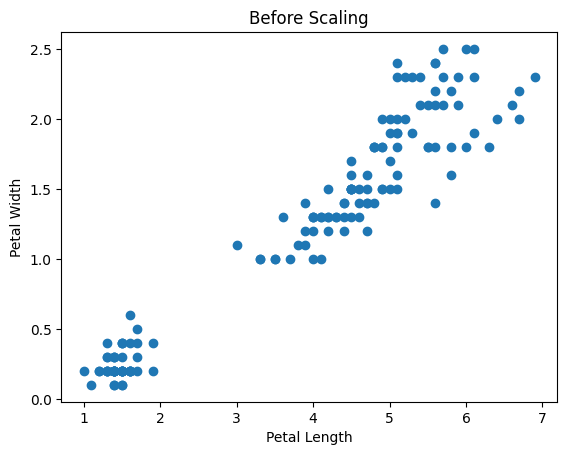

In [8]:
plt.scatter(
    df['petal length (cm)'],
    df['petal width (cm)']
)

plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.title('Before Scaling')

plt.show()

In [9]:
scaler = MinMaxScaler()

df_scaled = scaler.fit_transform(df)

df_scaled = pd.DataFrame(
    df_scaled,
    columns=[
        'petal length (cm)',
        'petal width (cm)'
    ]
)

print("\nScaled Dataset:\n")
print(df_scaled.head())


Scaled Dataset:

   petal length (cm)  petal width (cm)
0           0.067797          0.041667
1           0.067797          0.041667
2           0.050847          0.041667
3           0.084746          0.041667
4           0.067797          0.041667


In [10]:
sse = []

k_range = range(1, 11)

for k in k_range:

    km = KMeans(
        n_clusters=k,
        random_state=42
    )

    km.fit(df_scaled)

    sse.append(km.inertia_)

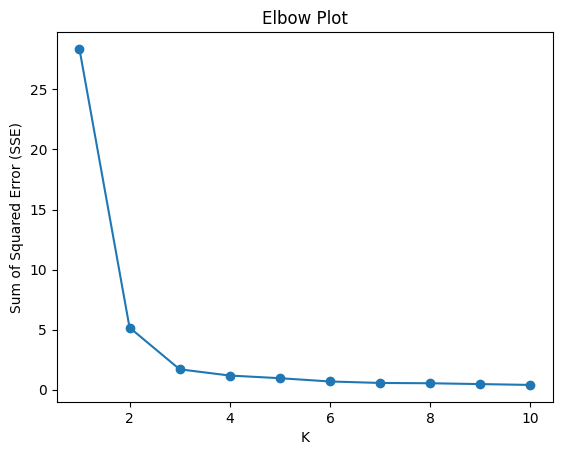

In [11]:
plt.plot(k_range, sse, marker='o')

plt.xlabel('K')
plt.ylabel('Sum of Squared Error (SSE)')
plt.title('Elbow Plot')

plt.show()

In [12]:
km = KMeans(
    n_clusters=3,
    random_state=42
)

y_predicted = km.fit_predict(df_scaled)
df_scaled['cluster'] = y_predicted

print("\nClustered Data:\n")
print(df_scaled.head())


Clustered Data:

   petal length (cm)  petal width (cm)  cluster
0           0.067797          0.041667        1
1           0.067797          0.041667        1
2           0.050847          0.041667        1
3           0.084746          0.041667        1
4           0.067797          0.041667        1


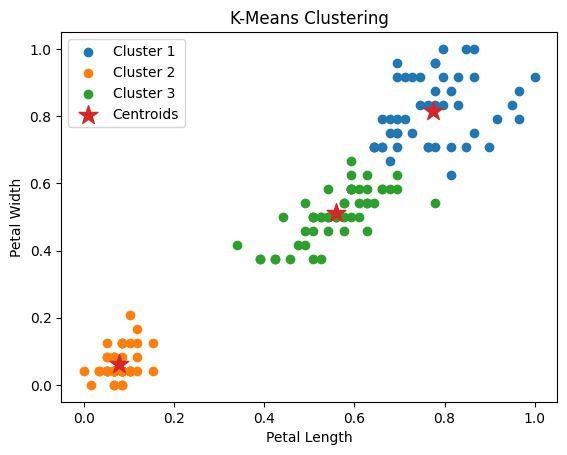

: 

In [ ]:
df1 = df_scaled[df_scaled.cluster == 0]
df2 = df_scaled[df_scaled.cluster == 1]
df3 = df_scaled[df_scaled.cluster == 2]

plt.scatter(
    df1['petal length (cm)'],
    df1['petal width (cm)'],
    label='Cluster 1'
)

plt.scatter(
    df2['petal length (cm)'],
    df2['petal width (cm)'],
    label='Cluster 2'
)

plt.scatter(
    df3['petal length (cm)'],
    df3['petal width (cm)'],
    label='Cluster 3'
)

plt.scatter(
    km.cluster_centers_[:,0],
    km.cluster_centers_[:,1],
    marker='*',
    s=200,
    label='Centroids'
)

plt.xlabel('Petal Length')
plt.ylabel('Petal Width')

plt.title('K-Means Clustering')

plt.legend()

plt.show()